<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

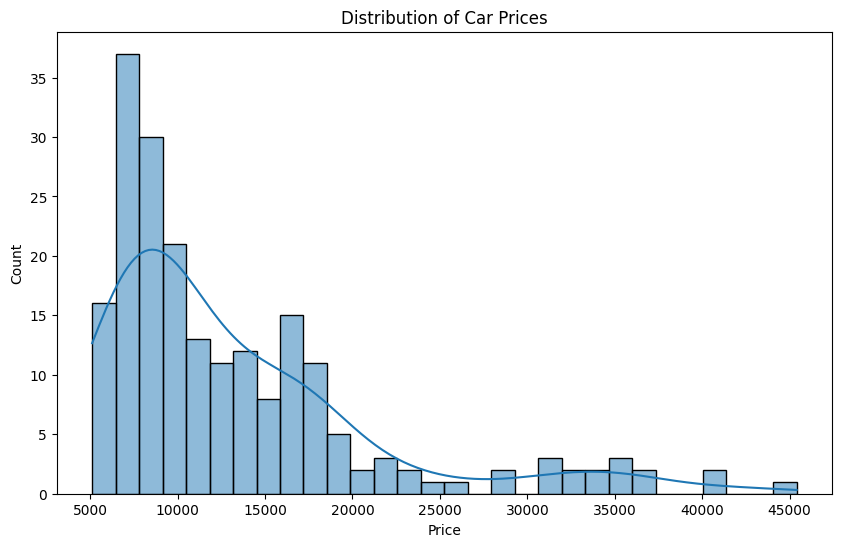

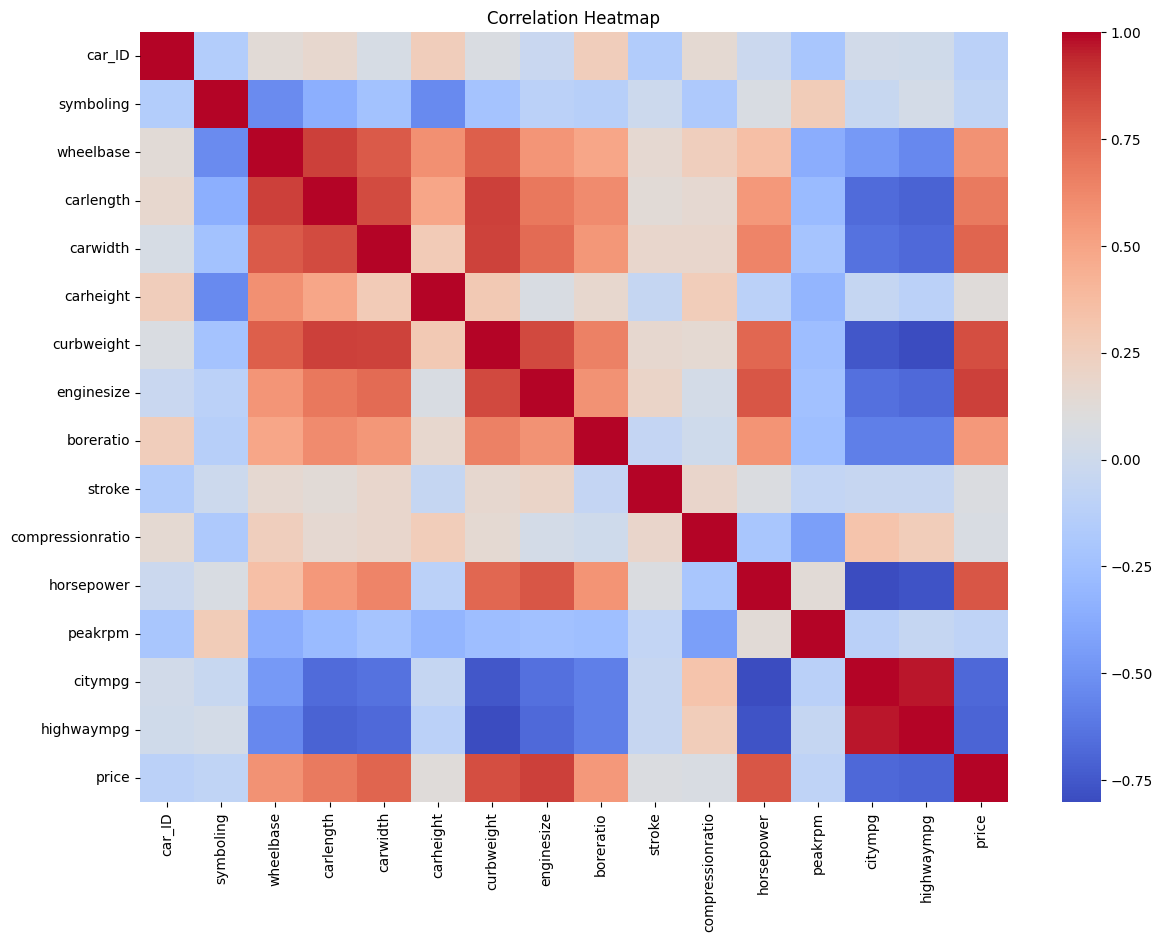

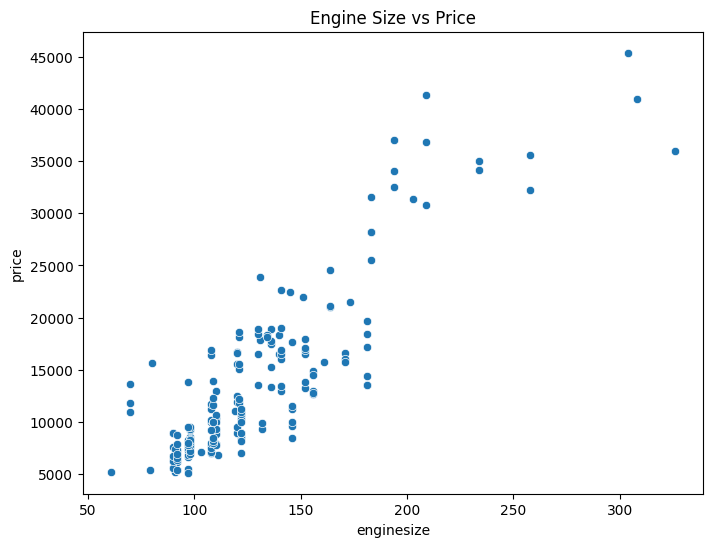

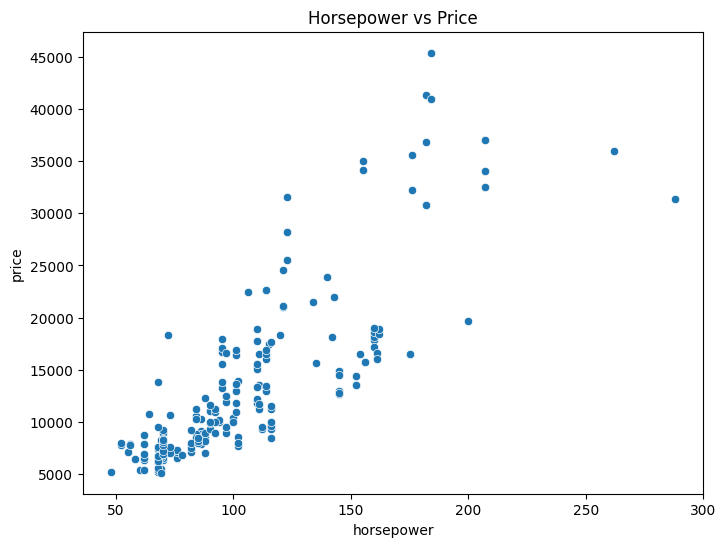

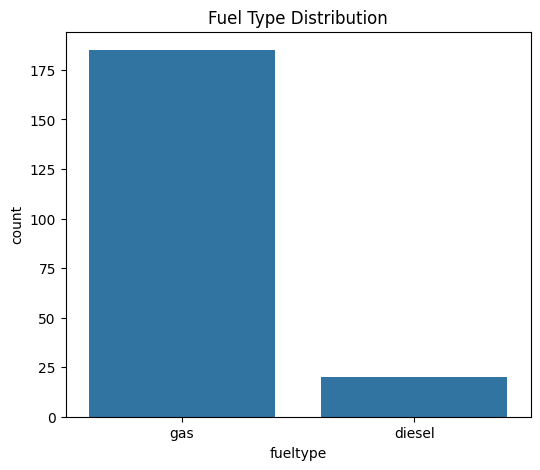

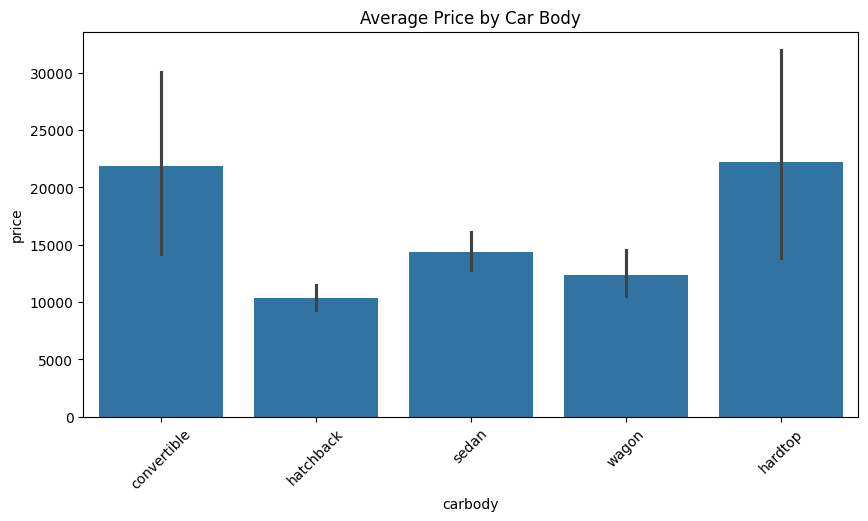

Feature Shape: (205, 25)
Target Shape: (205,)
Training Samples: 164
Testing Samples: 41
Linear Regression Model Trained Successfully!
Linear Regression Performance
------------------------------
MAE : 2087.31
RMSE: 3508.01
R² Score: 0.8441
Random Forest Model Trained Successfully!
Random Forest Performance
-------------------------
MAE : 1303.81
RMSE: 1838.66
R² Score: 0.9572


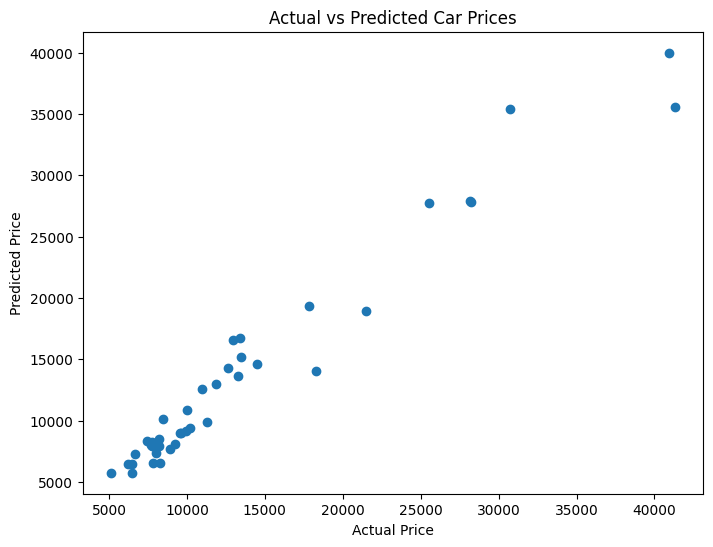

Predicted Car Price: 35378.15
Actual Car Price: 30760.0


In [31]:
# CodeAlpha Data Science Internship

# Task 3: Car Price Prediction with Machine Learning


# Import Required Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

# Load the Dataset
df = pd.read_csv("CarPrice_Assignment.csv")

# Display the Dataset
df.head()

# Understanding the Dataset
df.shape
df.columns
df.info()
df.describe()

# Data Cleaning
# Check missing values
df.isnull().sum()
# Check duplicate rows
df.duplicated().sum()
# Remove duplicates (if any)
df = df.drop_duplicates()
# Verify shape
df.shape

# 📊 Exploratory Data Analysis (EDA)

## Distribution of Car Prices
plt.figure(figsize=(10,6))
sns.histplot(df['price'], bins=30, kde=True)
plt.title("Distribution of Car Prices")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

## Correlation Heatmap
plt.figure(figsize=(14,10))
sns.heatmap(df.select_dtypes(include='number').corr(),cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## Engine Size vs Car Price
plt.figure(figsize=(8,6))
sns.scatterplot(x='enginesize',y='price',data=df)
plt.title("Engine Size vs Price")
plt.show()

## Horsepower vs Car Price
plt.figure(figsize=(8,6))
sns.scatterplot(x='horsepower',y='price',data=df)
plt.title("Horsepower vs Price")
plt.show()

## Fuel Type Distribution
plt.figure(figsize=(6,5))
sns.countplot(x='fueltype', data=df)
plt.title("Fuel Type Distribution")
plt.show()

## Average Price by Car Body
plt.figure(figsize=(10,5))
sns.barplot(x='carbody',y='price',data=df)
plt.xticks(rotation=45)
plt.title("Average Price by Car Body")
plt.show()

# Feature Encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
# Encode all categorical columns
for column in df.select_dtypes(include='object').columns:
    df[column] = le.fit_transform(df[column])
df.head()
# Define Features and Target Variable
X = df.drop('price', axis=1)
y = df['price']
print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)
# Split the Dataset
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

# Linear Regression Model
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("Linear Regression Model Trained Successfully!")
# Linear Regression Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
mae = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2 = r2_score(y_test, y_pred_lr)
print("Linear Regression Performance")
print("------------------------------")
print("MAE :", round(mae,2))
print("RMSE:", round(rmse,2))
print("R² Score:", round(r2,4))

# Random Forest Regression Model
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100,random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest Model Trained Successfully!")
# Random Forest Evaluation
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)
print("Random Forest Performance")
print("-------------------------")
print("MAE :", round(mae_rf,2))
print("RMSE:", round(rmse_rf,2))
print("R² Score:", round(r2_rf,4))

## Model Comparison

# Actual vs Predicted Prices (Random Forest)
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")
plt.show()

# Sample Car Price Prediction
sample_car = X_test.iloc[[0]]
predicted_price = rf.predict(sample_car)
print("Predicted Car Price:", round(predicted_price[0], 2))
print("Actual Car Price:", y_test.iloc[0])
